In [2]:
import pandas as pd

df = pd.read_csv("../data/jobs_raw.csv")
df.head()

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nDataset info:")
print(df.info())

Shape of dataset: (123849, 31)

Column names:
Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='str')

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str

In [3]:
columns_to_keep = [
    "title",
    "company_name",
    "description",
    "location",
    "formatted_work_type",
    "formatted_experience_level",
    "views",
    "applies",
    "normalized_salary",
    "currency",
    "compensation_type",
]

df = df[columns_to_keep]

print(df.shape)
df.head()

(123849, 11)


,title,company_name,description,location,formatted_work_type,formatted_experience_level,views,applies,normalized_salary,currency,compensation_type
0,Marketing Coordinator,Corcoran Sawyer Smith,Job descriptionA leading real estate firm in N...,"Princeton, NJ",Full-time,NaN,20.0,2.0,38480.0,USD,BASE_SALARY
1,Mental Health Therapist/Counselor,NaN,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",Full-time,NaN,1.0,NaN,83200.0,USD,BASE_SALARY
2,Assitant Restaurant Manager,The National Exemplar,The National Exemplar is accepting application...,"Cincinnati, OH",Full-time,NaN,8.0,NaN,55000.0,USD,BASE_SALARY
3,Senior Elder Law / Trusts and Estates Associat...,"Abrams Fensterman, LLP",Senior Associate Attorney - Elder Law / Trusts...,"New Hyde Park, NY",Full-time,NaN,16.0,NaN,157500.0,USD,BASE_SALARY
4,Service Technician,NaN,Looking for HVAC service tech with experience ...,"Burlington, IA",Full-time,NaN,3.0,NaN,70000.0,USD,BASE_SALARY


In [11]:
df["formatted_work_type"] = df["formatted_work_type"].str.lower()

internships = df[df["formatted_work_type"] == "internship"]

print("Internship dataset shape:", internships.shape)
internships.head()

Internship dataset shape: (983, 11)


,title,company_name,description,location,formatted_work_type,formatted_experience_level,views,applies,normalized_salary,currency,compensation_type
5,economic development and planning intern,Downtown Raleigh Alliance,Job summary:The Economic Development & Plannin...,"Raleigh, NC",internship,NaN,9.0,4.0,35360.0,USD,BASE_SALARY
103,digital marketing intern,Lead Lab,"We are looking for a creative, self-motivated ...","Redmond, WA",internship,NaN,7.0,3.0,52000.0,USD,BASE_SALARY
110,events & communications assistant,San José Clinic,San José ClinicExxonMobil Foundation Community...,"Houston, TX",internship,NaN,5.0,NaN,50400.0,USD,BASE_SALARY
148,photonics layout intern,Axalume,Job descriptionAxalume developed proprietary t...,"San Diego, CA",internship,NaN,52.0,11.0,NaN,NaN,NaN
149,summer intern for women international company,Women choice,“These are the hard times in which genius shou...,United States,internship,NaN,55.0,5.0,NaN,NaN,NaN


In [12]:
print("Number of internships with salary",internships["normalized_salary"].notnull().sum())

Number of internships with salary 247


In [13]:
skills = ["python", "sql", "excel", "tableau", "power bi", "aws", "r", "java"]

internships["description"] = internships["description"].str.lower()

for skill in skills:
    internships[skill] = internships["description"].str.contains(skill)

skill_counts = internships[skills].sum().sort_values(ascending=False)
print(skill_counts)

r           983
excel       554
aws         168
python       76
sql          49
java         31
tableau      13
power bi      8
dtype: int64


In [14]:
skill_percent = (skill_counts / len(internships)) * 100
print(skill_percent)

r           100.000000
excel        56.358087
aws          17.090539
python        7.731434
sql           4.984741
java          3.153611
tableau       1.322482
power bi      0.813835
dtype: float64


In [31]:
internships = internships[internships["location"] != "United States"]

internships["location"] = internships["location"].replace("New York City Metropolitan Area", "New York, NY")

location_counts = internships["location"].value_counts().head(10)
print(location_counts)
print("")
# internships["formatted_work_type"].value_counts()

location
New York, NY         53
Boston, MA           18
Los Angeles, CA      17
Atlanta, GA          15
Miami, FL            13
Chicago, IL          13
San Francisco, CA    11
Charlotte, NC        11
San Diego, CA        10
Davidson, NC         10
Name: count, dtype: int64



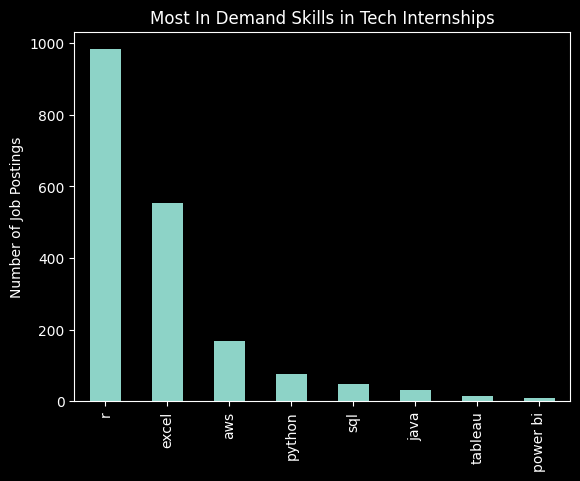

In [29]:
import matplotlib.pyplot as plt

skill_counts.plot(kind="bar")

plt.title("Most In Demand Skills in Tech Internships")
plt.ylabel("Number of Job Postings")
plt.show()

In [32]:
internships.to_csv("../cleaned_data/jobs_cleaned.csv", index=False)